# Compare_Real_Generated_DDM_Params_v2.4.4

这个 notebook 用来比较：

1. 真实数据中 `Matching` 试次的行为趋势
2. `v2.4.4` 生成数据中的 `Matching` 行为趋势
3. 两者在 `v / a / t / z` 与 `omit_rate` 上是否能对得上

与上一版不同的是：

- 这里把 `NA` / 漏答当作真实任务的一部分，而不是简单删除。
- 参数估计时，只使用 **answered trials**；
- 漏答率 `omit_rate` 单独作为一个重要拟合指标。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 240)

BASE_DIR = Path.cwd().parent.parent
REAL_PATH = BASE_DIR / '2_Data' / 'Real_Data' / 'EXP_data_combined.csv'
GEN_PATH = BASE_DIR / '2_Data' / 'Generate_Data' / 'Generate_Data_v2.4.4_checks' / 'gp_ddm_v2.4.4_large.csv'
FIG_DIR = BASE_DIR / '3_Figures' / 'Compare_Real_Generated_DDM_Params_v2.4.4'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('真实数据路径:', REAL_PATH)
print('生成数据路径:', GEN_PATH)
print('图表输出目录:', FIG_DIR)

真实数据路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Real_Data\EXP_data_combined.csv
生成数据路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.4_checks\gp_ddm_v2.4.4_large.csv
图表输出目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Compare_Real_Generated_DDM_Params_v2.4.4


## 一、预处理与 Matching 恢复

真实数据来自 Self-Matching Task，因此先恢复 `Matching / NonMatching`。

这里采用的规则是：

`Matching = (CorrectKey == getMatchKey(subjectID))`

也就是直接利用真实导出数据里的 `CorrectKey`，配合实验代码中的 `{f, j, j, f}` 循环 match key。

In [2]:
real_raw = pd.read_csv(REAL_PATH)
gen_raw = pd.read_csv(GEN_PATH)

def get_match_key(subject_id):
    keys = ['f', 'j', 'j', 'f']
    return keys[(int(subject_id) - 1) % 4]

real = real_raw.copy()
real = real.rename(columns={'subjectID': 'subject', 'Label': 'label', 'Correct': 'correct', 'RT': 'rt_s'})
real['subject_uid'] = real['GroupInfo'].astype(str)
real['label'] = real['label'].astype(str).str.lower()
real['CorrectKey'] = real['CorrectKey'].astype(str).str.lower()
real['match_key'] = real['subject'].apply(get_match_key)
real['matching'] = np.where(real['CorrectKey'] == real['match_key'], 'Matching', 'NonMatching')
real['T_ms'] = pd.to_numeric(real['T'], errors='coerce') * 1000.0
real['W_ms'] = pd.to_numeric(real['W'], errors='coerce') * 1000.0
real['rt_s'] = pd.to_numeric(real['rt_s'], errors='coerce')
real['answered'] = real['rt_s'].notna().astype(int)
real['omit_rate_trial'] = 1 - real['answered']
real['correct'] = pd.to_numeric(real['correct'], errors='coerce').fillna(0).astype(int)

gen = gen_raw.copy()
gen['subject_uid'] = gen['subject'].astype(str)
gen['label'] = gen['label'].astype(str).str.lower()
gen['T_ms'] = pd.to_numeric(gen['T'], errors='coerce')
gen['W_ms'] = pd.to_numeric(gen['W'], errors='coerce')
gen['rt_s'] = pd.to_numeric(gen['RT'], errors='coerce')
gen['answered'] = pd.to_numeric(gen['responded'], errors='coerce').fillna(0).astype(int)
gen['omit_rate_trial'] = pd.to_numeric(gen['omission'], errors='coerce').fillna(0).astype(int)
gen['correct'] = pd.to_numeric(gen['correct'], errors='coerce').fillna(0).astype(int)
gen['matching'] = 'Matching'

print('真实数据 Matching/NonMatching:')
display(real['matching'].value_counts())
print('真实数据总体漏答率:', real['omit_rate_trial'].mean())
print('生成数据总体漏答率:', gen['omit_rate_trial'].mean())

真实数据 Matching/NonMatching:


matching
NonMatching    13308
Matching       13308
Name: count, dtype: int64

真实数据总体漏答率: 0.36384129846708746
生成数据总体漏答率: 0.4287


In [3]:
# 只保留 Matching 主分析
real_match = real.copy()
if 'stage' in real_match.columns:
    real_match = real_match[real_match['stage'].astype(str).str.lower() == 'formal'].copy()
real_match = real_match[real_match['matching'] == 'Matching'].copy()

real_conditions = (
    real_match[['P', 'T_ms', 'W_ms']]
      .drop_duplicates()
      .sort_values(['P', 'T_ms', 'W_ms'])
      .reset_index(drop=True)
)
real_conditions['condition_id'] = [f'C{i+1}' for i in range(len(real_conditions))]
real_match = real_match.merge(real_conditions, on=['P', 'T_ms', 'W_ms'], how='left')
display(real_conditions)

,P,T_ms,W_ms,condition_id
0,0,30.0,300.0,C1
1,0,30.0,600.0,C2
2,8,100.0,1100.0,C3
3,120,30.0,600.0,C4
4,120,80.0,600.0,C5
5,120,500.0,1500.0,C6


In [4]:
# 生成数据映射到最近的真实条件
scale_P = max(real_conditions['P'].max() - real_conditions['P'].min(), 1)
scale_T = max(real_conditions['T_ms'].max() - real_conditions['T_ms'].min(), 1)
scale_W = max(real_conditions['W_ms'].max() - real_conditions['W_ms'].min(), 1)

gen_subject_conditions = gen[['subject', 'P', 'T_ms', 'W_ms']].drop_duplicates().copy()

def nearest_real_condition(row):
    d = (
        ((real_conditions['P'] - row['P']) / scale_P) ** 2
        + ((real_conditions['T_ms'] - row['T_ms']) / scale_T) ** 2
        + ((real_conditions['W_ms'] - row['W_ms']) / scale_W) ** 2
    )
    idx = d.idxmin()
    return real_conditions.loc[idx, ['condition_id', 'P', 'T_ms', 'W_ms']]

assigned = gen_subject_conditions.apply(nearest_real_condition, axis=1)
assigned = pd.concat([gen_subject_conditions[['subject']].reset_index(drop=True), assigned.reset_index(drop=True)], axis=1)
assigned = assigned.rename(columns={'P': 'P_target', 'T_ms': 'T_ms_target', 'W_ms': 'W_ms_target'})
gen = gen.merge(assigned, on='subject', how='left')

print('生成数据映射到真实条件后的 subject 分布:')
display(assigned['condition_id'].value_counts().sort_index())

生成数据映射到真实条件后的 subject 分布:


condition_id
C1    140
C2    105
C3    445
C4     91
C5    613
C6    606
Name: count, dtype: int64

## 二、带 NA 的参数估计逻辑

这里有一个关键改动：

- `omit_rate` 作为单独行为指标比较；
- `v / a / t / z` 只在 **answered trials** 上估计。

原因是：漏答不是简单错误，不能直接把它塞进标准二元 DDM 的正确率里，否则会把“没反应”和“反应错误”混在一起。

In [5]:
def ez_diffusion_answered_only(df_group, rt_col='rt_s', correct_col='correct', answered_col='answered', s=0.1):
    n_total = len(df_group)
    omit_rate = 1.0 - df_group[answered_col].mean()
    answered_df = df_group[df_group[answered_col] == 1].copy()
    n_answered = len(answered_df)
    if n_answered < 4:
        return pd.Series({'omit_rate': omit_rate, 'pc_answered': np.nan, 'mrt': np.nan, 'vrt': np.nan, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_answered': n_answered, 'valid_ez': 0})

    pc_raw = answered_df[correct_col].mean()
    pc = (answered_df[correct_col].sum() + 0.5) / (n_answered + 1.0)
    pc = float(np.clip(pc, 1e-4, 1 - 1e-4))
    correct_rt = answered_df.loc[(answered_df[correct_col] == 1) & answered_df[rt_col].notna(), rt_col]
    if len(correct_rt) < 3:
        return pd.Series({'omit_rate': omit_rate, 'pc_answered': pc_raw, 'mrt': np.nan, 'vrt': np.nan, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_answered': n_answered, 'valid_ez': 0})

    mrt = correct_rt.mean()
    vrt = correct_rt.var(ddof=1)
    if (pc <= 0.5) or (vrt <= 0) or np.isnan(vrt):
        return pd.Series({'omit_rate': omit_rate, 'pc_answered': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_answered': n_answered, 'valid_ez': 0})

    logit_p = np.log(pc / (1 - pc))
    x = logit_p * (pc**2 * logit_p - pc * logit_p + pc - 0.5) / vrt
    if x <= 0 or np.isnan(x):
        return pd.Series({'omit_rate': omit_rate, 'pc_answered': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_answered': n_answered, 'valid_ez': 0})

    v = s * np.power(x, 0.25)
    a = (s ** 2) * logit_p / v
    y = (-v * a) / (s ** 2)
    mdt = (a / (2 * v)) * ((1 - np.exp(y)) / (1 + np.exp(y)))
    ter = mrt - mdt
    z = a / 2.0
    valid = int((not np.any(np.isnan([v, a, ter, z]))) and (a > 0) and (ter >= 0))

    return pd.Series({'omit_rate': omit_rate, 'pc_answered': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': v if valid else np.nan, 'a_est': a if valid else np.nan, 't_est': ter if valid else np.nan, 'z_est': z if valid else np.nan, 'n_total': n_total, 'n_answered': n_answered, 'valid_ez': valid})

In [6]:
def estimate_params(df, dataset_name):
    if dataset_name == 'real_matching':
        group_cols = ['subject_uid', 'condition_id', 'P', 'T_ms', 'W_ms', 'label']
    else:
        group_cols = ['subject_uid', 'condition_id', 'P_target', 'T_ms_target', 'W_ms_target', 'label']

    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(ez_diffusion_answered_only(g).to_dict())
        rows.append(row)
    out = pd.DataFrame(rows)
    out['dataset'] = dataset_name

    if dataset_name == 'generated_matching':
        latent = (
            df.groupby(group_cols, as_index=False)
              .agg(
                  v_latent=('v', 'mean'),
                  a_latent=('a', 'mean'),
                  t_latent=('t0', 'mean'),
                  z_latent=('z', 'mean'),
              )
        )
        out = out.merge(latent, on=group_cols, how='left')
    return out

In [7]:
real_est = estimate_params(real_match, 'real_matching')
gen_est = estimate_params(gen, 'generated_matching')

print('真实 Matching 参数估计有效数:')
display(real_est['valid_ez'].value_counts(dropna=False))
print('生成 Matching 参数估计有效数:')
display(gen_est['valid_ez'].value_counts(dropna=False))
display(real_est.head())
display(gen_est.head())

真实 Matching 参数估计有效数:


valid_ez
1.0    75
0.0    17
Name: count, dtype: int64

生成 Matching 参数估计有效数:


valid_ez
1.0    3530
0.0     470
Name: count, dtype: int64

,subject_uid,condition_id,P,T_ms,W_ms,label,omit_rate,pc_answered,mrt,vrt,v_est,a_est,t_est,z_est,n_total,n_answered,valid_ez,dataset
0,group1_1,C1,0,30.0,300.0,self,0.807692,0.76000,0.263868,0.001193,0.252296,0.043545,0.220720,0.021772,130.0,25.0,1.0,real_matching
1,group1_1,C1,0,30.0,300.0,stranger,0.838462,0.52381,0.252243,0.000853,0.024037,0.037847,0.216458,0.018923,130.0,21.0,1.0,real_matching
2,group1_2,C1,0,30.0,300.0,self,0.607692,0.45098,0.275991,0.001247,NaN,NaN,NaN,NaN,130.0,51.0,0.0,real_matching
3,group1_2,C1,0,30.0,300.0,stranger,0.707692,0.50000,0.269485,0.001245,NaN,NaN,NaN,NaN,130.0,38.0,0.0,real_matching
4,group1_3,C1,0,30.0,300.0,self,0.823077,0.73913,0.266592,0.000878,0.248093,0.039920,0.229717,0.019960,130.0,23.0,1.0,real_matching


,subject_uid,condition_id,P_target,T_ms_target,W_ms_target,label,omit_rate,pc_answered,mrt,vrt,v_est,a_est,t_est,z_est,n_total,n_answered,valid_ez,dataset,v_latent,a_latent,t_latent,z_latent
0,1,C6,120,500.0,1500.0,self,0.000000,1.000000,0.512600,0.025143,0.287632,0.142921,0.272169,0.071461,30.0,30.0,1.0,generated_matching,3.968541,2.307258,0.2,1.153629
1,1,C6,120,500.0,1500.0,stranger,0.366667,0.789474,0.761133,0.045934,0.112428,0.110005,0.492061,0.055002,30.0,19.0,1.0,generated_matching,0.412638,2.334114,0.2,1.167057
2,10,C1,0,30.0,300.0,self,0.766667,1.000000,0.343286,0.000518,0.617824,0.043832,0.312247,0.021916,30.0,7.0,1.0,generated_matching,2.724730,1.840048,0.2,0.920024
3,10,C1,0,30.0,300.0,stranger,0.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,3.0,0.0,generated_matching,0.836531,1.798515,0.2,0.899258
4,100,C5,120,80.0,600.0,self,0.133333,0.961538,0.691760,0.062209,0.191580,0.147886,0.348681,0.073943,30.0,26.0,1.0,generated_matching,1.984541,2.356863,0.2,1.178432


## 三、条件层面的比较表

In [8]:
real_cond = (
    real_est.groupby(['condition_id', 'label'], as_index=False)
      .agg(
          P=('P', 'mean'),
          T_ms=('T_ms', 'mean'),
          W_ms=('W_ms', 'mean'),
          omit_real=('omit_rate', 'mean'),
          v_real=('v_est', 'mean'),
          a_real=('a_est', 'mean'),
          t_real=('t_est', 'mean'),
          z_real=('z_est', 'mean'),
          pc_real=('pc_answered', 'mean'),
      )
)

gen_cond_est = (
    gen_est.groupby(['condition_id', 'label'], as_index=False)
      .agg(
          P=('P_target', 'mean'),
          T_ms=('T_ms_target', 'mean'),
          W_ms=('W_ms_target', 'mean'),
          omit_gen=('omit_rate', 'mean'),
          v_gen_est=('v_est', 'mean'),
          a_gen_est=('a_est', 'mean'),
          t_gen_est=('t_est', 'mean'),
          z_gen_est=('z_est', 'mean'),
          pc_gen=('pc_answered', 'mean'),
      )
)

gen_cond_latent = (
    gen_est.groupby(['condition_id', 'label'], as_index=False)
      .agg(
          v_gen_latent=('v_latent', 'mean'),
          a_gen_latent=('a_latent', 'mean'),
          t_gen_latent=('t_latent', 'mean'),
          z_gen_latent=('z_latent', 'mean'),
      )
)

compare_cond = (
    real_cond
      .merge(gen_cond_est, on=['condition_id', 'label', 'P', 'T_ms', 'W_ms'], how='outer')
      .merge(gen_cond_latent, on=['condition_id', 'label'], how='outer')
      .sort_values(['condition_id', 'label'])
      .reset_index(drop=True)
)
compare_cond['condition_text'] = compare_cond.apply(lambda r: f"{r['condition_id']} | P={int(r['P'])}, T={int(r['T_ms'])}, W={int(r['W_ms'])}", axis=1)
display(compare_cond)

,condition_id,label,P,T_ms,W_ms,omit_real,v_real,a_real,t_real,z_real,pc_real,omit_gen,v_gen_est,a_gen_est,t_gen_est,z_gen_est,pc_gen,v_gen_latent,a_gen_latent,t_gen_latent,z_gen_latent,condition_text
0,C1,self,0.0,30.0,300.0,0.756731,0.255681,0.041645,0.221604,0.020822,0.713525,0.729762,0.404330,0.045388,0.235758,0.022694,0.816564,2.397726,1.407597,0.2,0.703799,"C1 | P=0, T=30, W=300"
1,C1,stranger,0.0,30.0,300.0,0.759615,0.267197,0.043079,0.219212,0.021539,0.707926,0.789762,0.250999,0.041693,0.226412,0.020846,0.591827,0.683371,1.424101,0.2,0.712050,"C1 | P=0, T=30, W=300"
2,C2,self,0.0,30.0,600.0,0.526496,0.106461,0.074801,0.301257,0.037401,0.653108,0.535238,0.271432,0.081246,0.304045,0.040623,0.897041,1.876058,1.927445,0.2,0.963722,"C2 | P=0, T=30, W=600"
3,C2,stranger,0.0,30.0,600.0,0.551282,0.053718,0.066579,0.263562,0.033289,0.474156,0.661587,0.131073,0.070083,0.318044,0.035041,0.677037,0.555445,1.940064,0.2,0.970032,"C2 | P=0, T=30, W=600"
4,C3,self,8.0,100.0,1100.0,0.042857,0.233526,0.107847,0.467461,0.053924,0.912724,0.218352,0.241714,0.132436,0.321741,0.066218,0.959179,2.370964,2.350334,0.2,1.175167,"C3 | P=8, T=100, W=1100"
5,C3,stranger,8.0,100.0,1100.0,0.087912,0.127152,0.097911,0.530026,0.048955,0.769452,0.457528,0.104865,0.103815,0.401860,0.051908,0.729403,0.648257,2.354180,0.2,1.177090,"C3 | P=8, T=100, W=1100"
6,C4,self,120.0,30.0,600.0,0.331538,0.169329,0.071940,0.312613,0.035970,0.663914,0.428571,0.183289,0.097577,0.311394,0.048789,0.812565,1.360214,1.775376,0.2,0.887688,"C4 | P=120, T=30, W=600"
7,C4,stranger,120.0,30.0,600.0,0.361538,0.085901,0.068600,0.256048,0.034300,0.524481,0.487179,0.097365,0.085709,0.336893,0.042854,0.614813,0.387303,1.783810,0.2,0.891905,"C4 | P=120, T=30, W=600"
8,C5,self,120.0,80.0,600.0,0.303297,0.266697,0.083562,0.387566,0.041781,0.873805,0.406036,0.328611,0.098845,0.295815,0.049422,0.950809,2.844771,2.027064,0.2,1.013532,"C5 | P=120, T=80, W=600"
9,C5,stranger,120.0,80.0,600.0,0.375824,0.177310,0.070644,0.409650,0.035322,0.666737,0.637085,0.161106,0.081460,0.349223,0.040730,0.735193,0.772833,2.028222,0.2,1.014111,"C5 | P=120, T=80, W=600"


In [9]:
def spearman_safe(df, x_col, y_col):
    temp = df[[x_col, y_col]].dropna()
    if len(temp) < 3:
        return np.nan
    return temp[x_col].corr(temp[y_col], method='spearman')

alignment_rows = []
for label in sorted(compare_cond['label'].dropna().unique()):
    sub = compare_cond[compare_cond['label'] == label]
    for param, real_col, gen_est_col, gen_latent_col in [
        ('omit_rate', 'omit_real', 'omit_gen', None),
        ('v', 'v_real', 'v_gen_est', 'v_gen_latent'),
        ('a', 'a_real', 'a_gen_est', 'a_gen_latent'),
        ('t', 't_real', 't_gen_est', 't_gen_latent'),
        ('z', 'z_real', 'z_gen_est', 'z_gen_latent'),
    ]:
        alignment_rows.append({
            'label': label,
            'param': param,
            'spearman_real_vs_gen_est': spearman_safe(sub, real_col, gen_est_col),
            'spearman_real_vs_gen_latent': np.nan if gen_latent_col is None else spearman_safe(sub, real_col, gen_latent_col),
        })
alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)

,label,param,spearman_real_vs_gen_est,spearman_real_vs_gen_latent
0,self,omit_rate,0.942857,NaN
1,self,v,0.771429,0.771429
2,self,a,0.942857,1.000000
3,self,t,0.257143,0.130931
4,self,z,0.942857,1.000000
5,stranger,omit_rate,1.000000,NaN
6,stranger,v,0.771429,0.771429
7,stranger,a,0.942857,0.885714
8,stranger,t,0.885714,0.392792
9,stranger,z,0.942857,0.885714


## 四、趋势图：加入 omit_rate 的主比较

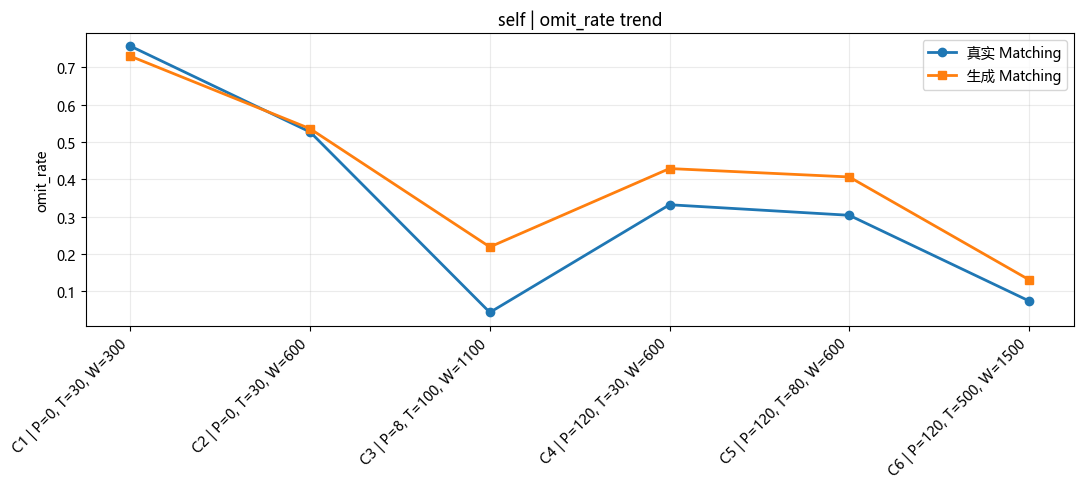

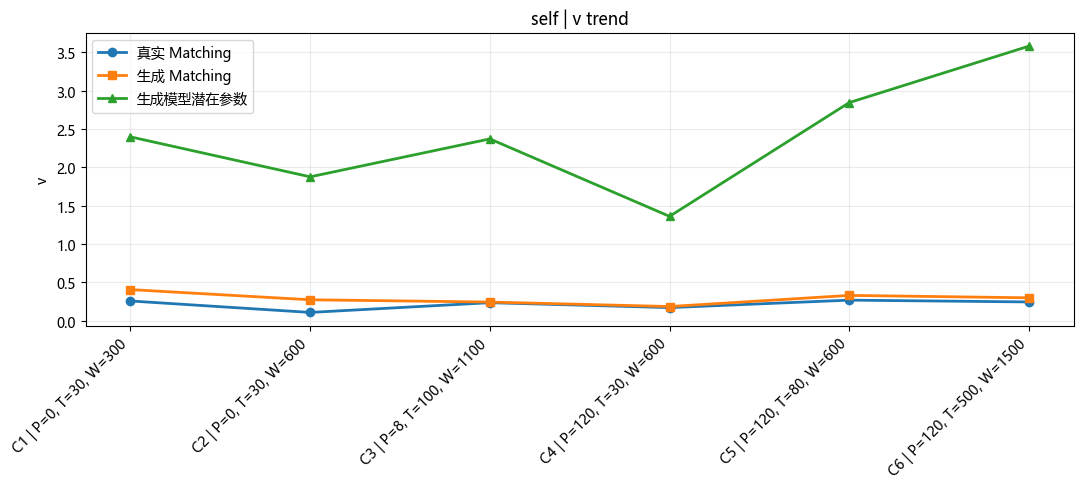

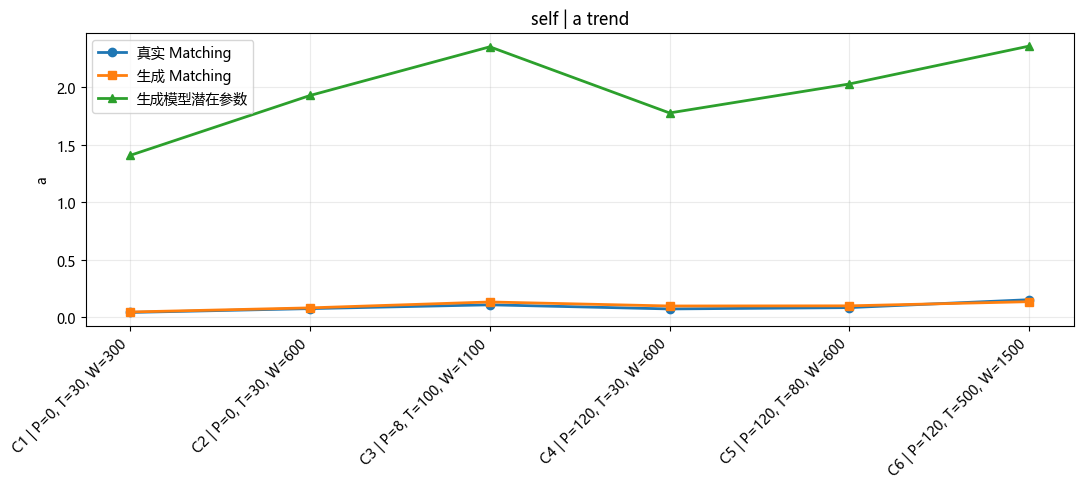

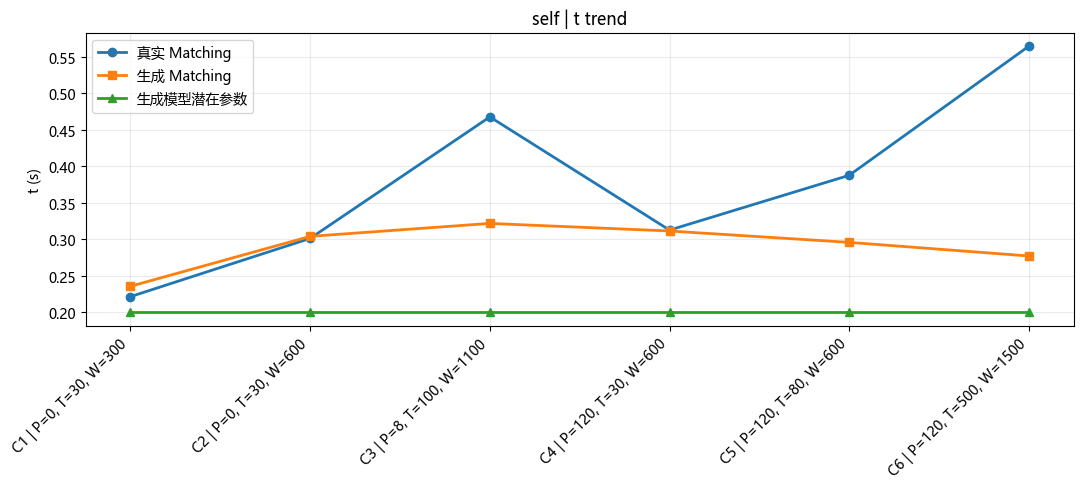

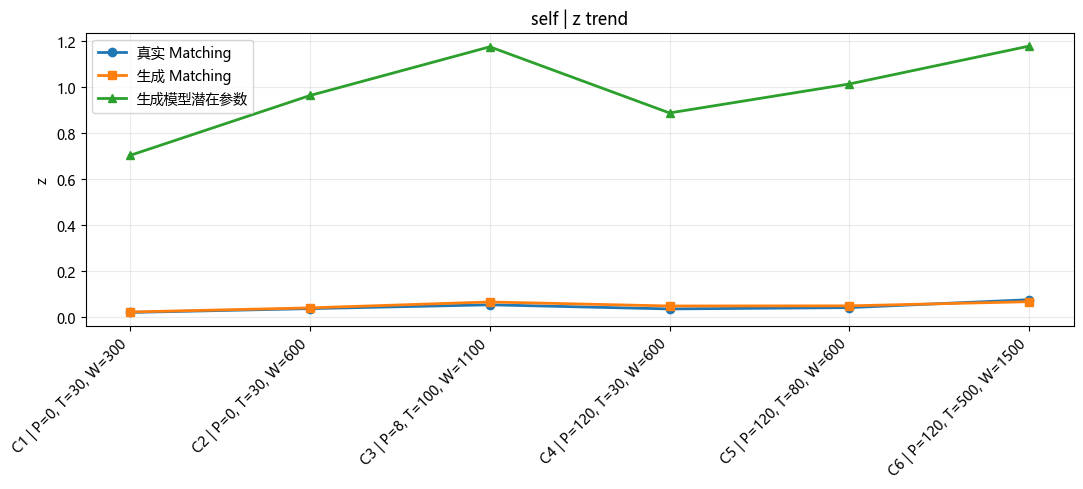

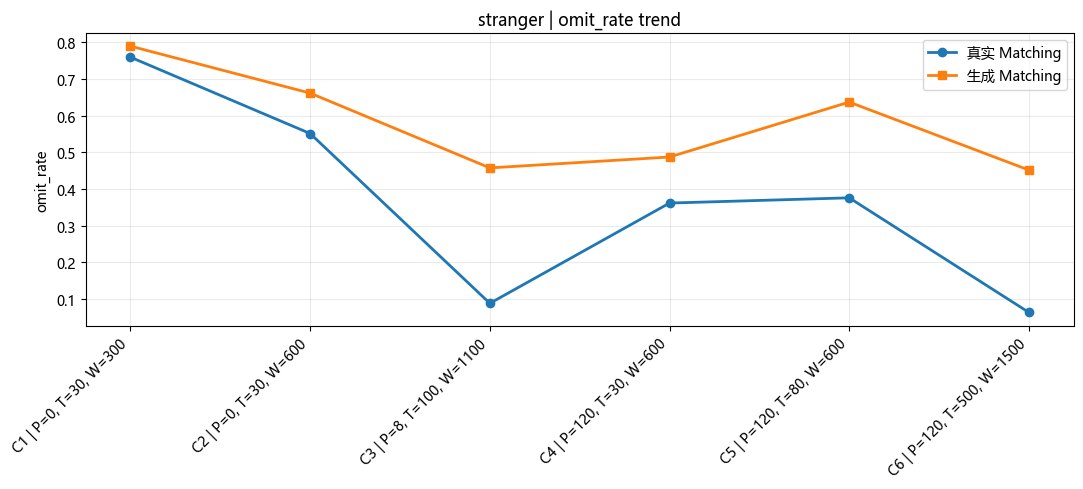

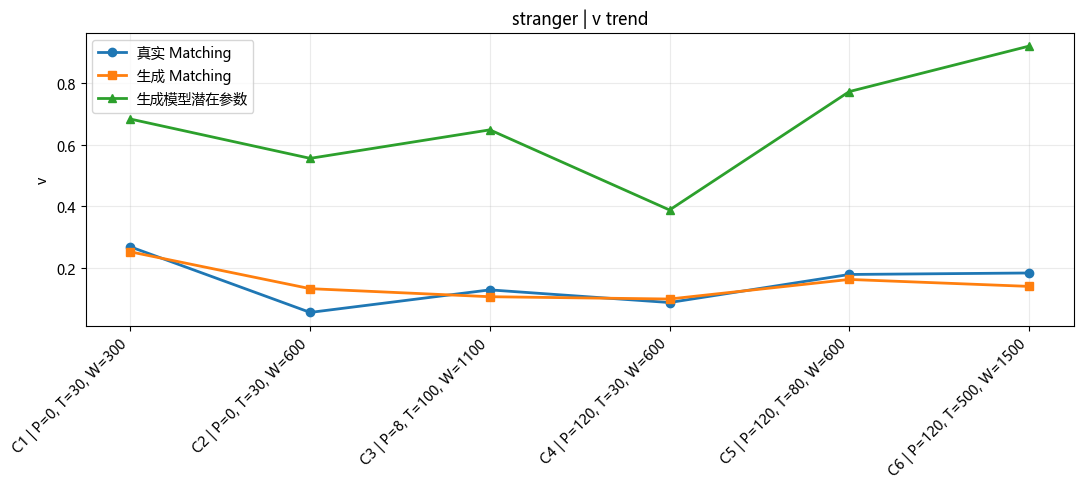

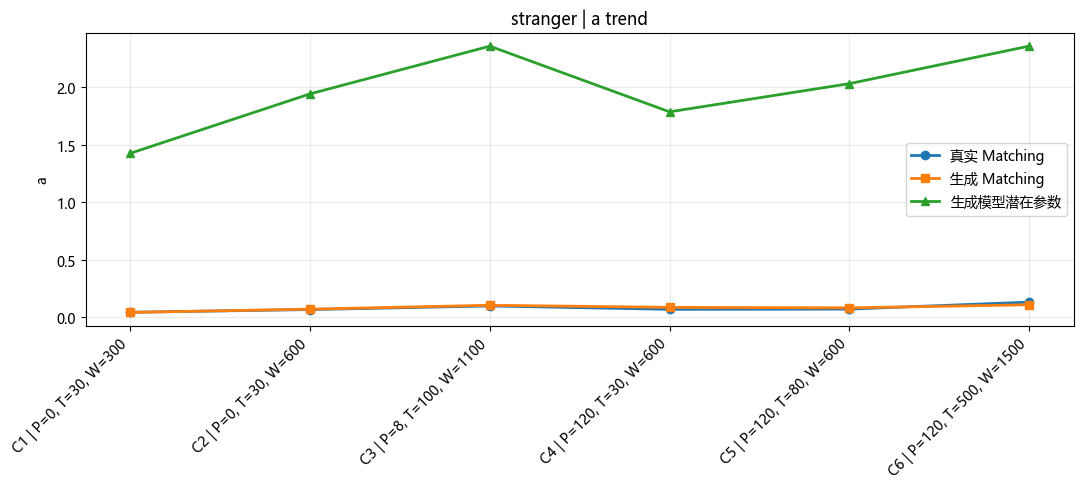

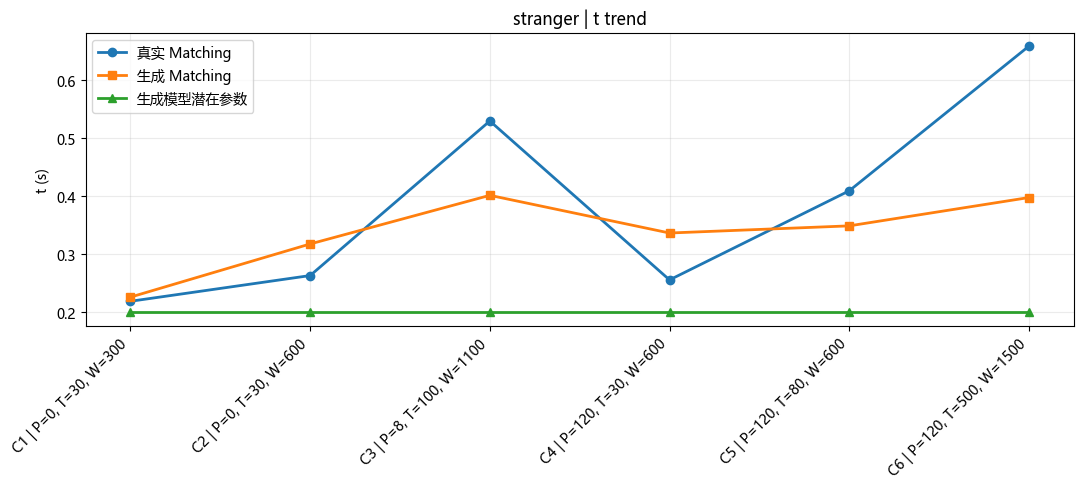

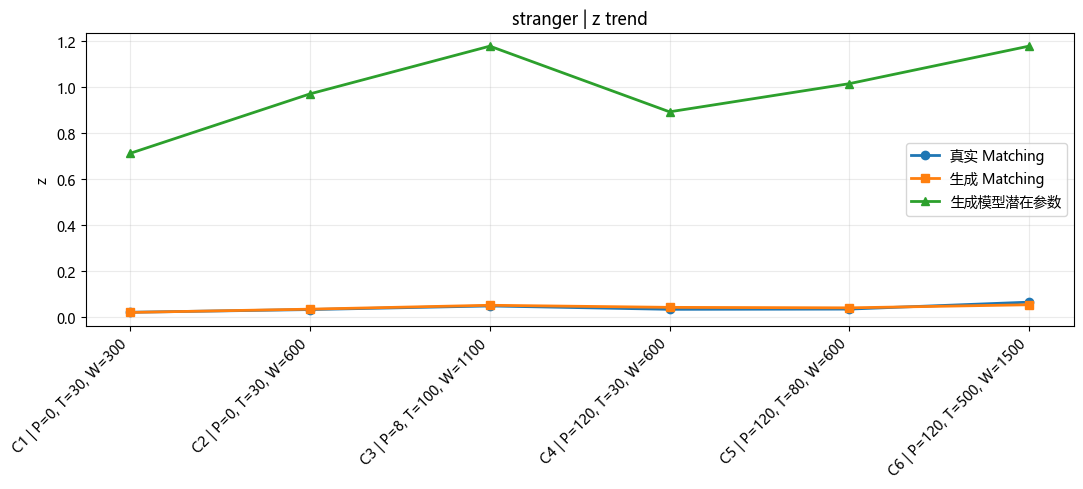

In [10]:
def plot_compare(compare_df, label_value, param, save_name=None):
    mapping = {
        'omit_rate': ('omit_real', 'omit_gen', None, 'omit_rate'),
        'v': ('v_real', 'v_gen_est', 'v_gen_latent', 'v'),
        'a': ('a_real', 'a_gen_est', 'a_gen_latent', 'a'),
        't': ('t_real', 't_gen_est', 't_gen_latent', 't (s)'),
        'z': ('z_real', 'z_gen_est', 'z_gen_latent', 'z'),
    }
    real_col, gen_est_col, gen_latent_col, ylabel = mapping[param]
    sub = compare_df[compare_df['label'] == label_value].sort_values(['P', 'T_ms', 'W_ms'])
    x = np.arange(len(sub))
    plt.figure(figsize=(11, 5))
    plt.plot(x, sub[real_col], marker='o', linewidth=2, label='真实 Matching')
    plt.plot(x, sub[gen_est_col], marker='s', linewidth=2, label='生成 Matching')
    if gen_latent_col is not None:
        plt.plot(x, sub[gen_latent_col], marker='^', linewidth=2, label='生成模型潜在参数')
    plt.xticks(x, sub['condition_text'], rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(f'{label_value} | {param} trend')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(compare_cond['label'].dropna().unique()):
    for param in ['omit_rate', 'v', 'a', 't', 'z']:
        plot_compare(compare_cond, label, param, save_name=f'{label}_{param}_compare_v2.4.4.png')

## 五、按 P / T / W 看边际趋势

In [11]:
long_rows = []
for _, row in compare_cond.iterrows():
    for source_name, cols in [
        ('真实 Matching', ('omit_real', 'v_real', 'a_real', 't_real', 'z_real')),
        ('生成 Matching', ('omit_gen', 'v_gen_est', 'a_gen_est', 't_gen_est', 'z_gen_est')),
        ('生成潜在参数', (np.nan, 'v_gen_latent', 'a_gen_latent', 't_gen_latent', 'z_gen_latent')),
    ]:
        omit_col, v_col, a_col, t_col, z_col = cols
        long_rows.append({
            'condition_id': row['condition_id'],
            'label': row['label'],
            'P': row['P'],
            'T_ms': row['T_ms'],
            'W_ms': row['W_ms'],
            'source': source_name,
            'omit_rate': np.nan if isinstance(omit_col, float) else row[omit_col],
            'v': row[v_col],
            'a': row[a_col],
            't': row[t_col],
            'z': row[z_col],
        })
compare_long = pd.DataFrame(long_rows)
display(compare_long.head())

,condition_id,label,P,T_ms,W_ms,source,omit_rate,v,a,t,z
0,C1,self,0.0,30.0,300.0,真实 Matching,0.756731,0.255681,0.041645,0.221604,0.020822
1,C1,self,0.0,30.0,300.0,生成 Matching,0.729762,0.404330,0.045388,0.235758,0.022694
2,C1,self,0.0,30.0,300.0,生成潜在参数,NaN,2.397726,1.407597,0.200000,0.703799
3,C1,stranger,0.0,30.0,300.0,真实 Matching,0.759615,0.267197,0.043079,0.219212,0.021539
4,C1,stranger,0.0,30.0,300.0,生成 Matching,0.789762,0.250999,0.041693,0.226412,0.020846


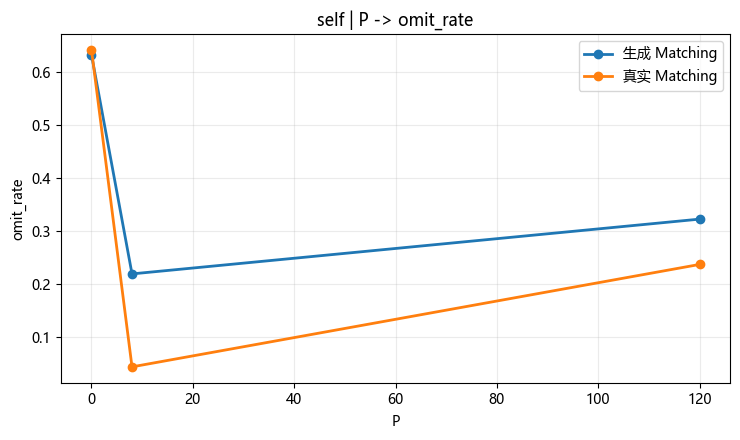

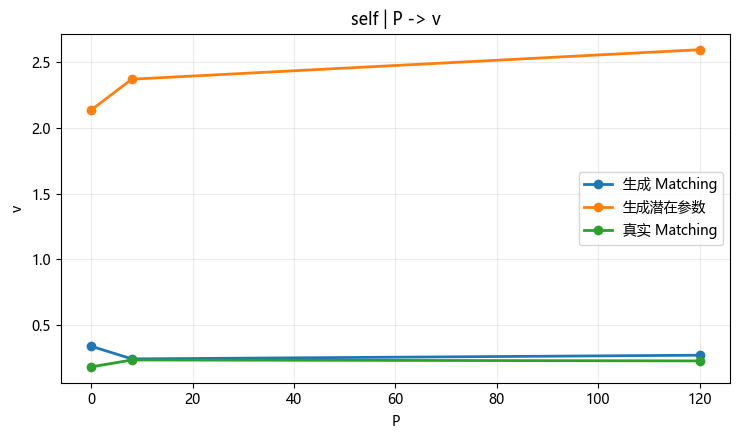

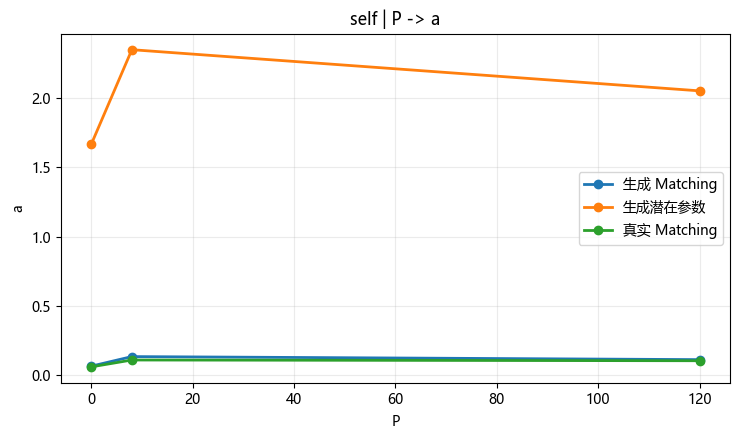

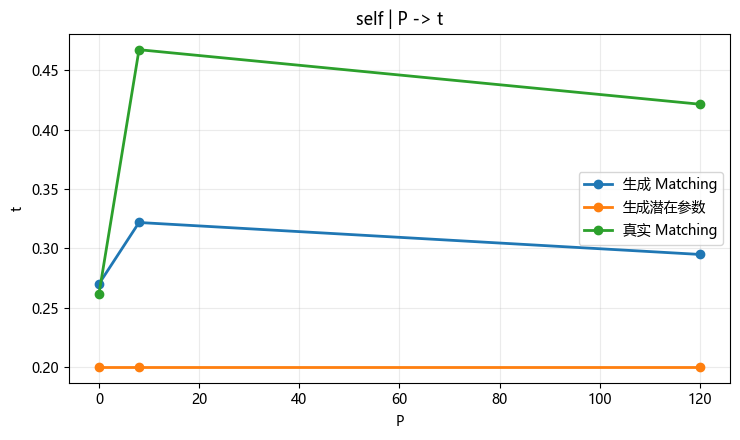

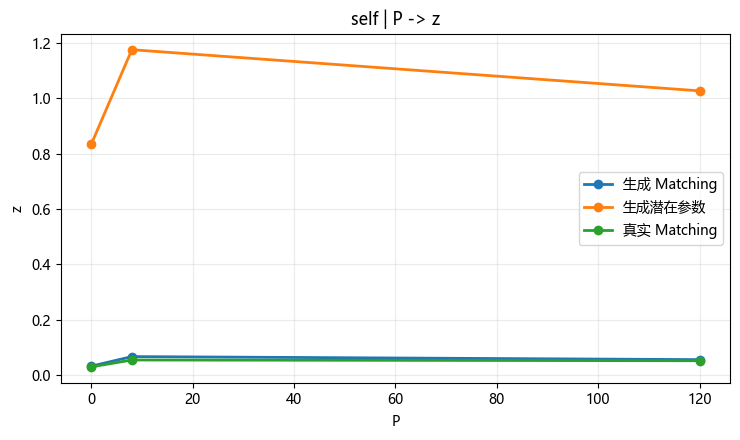

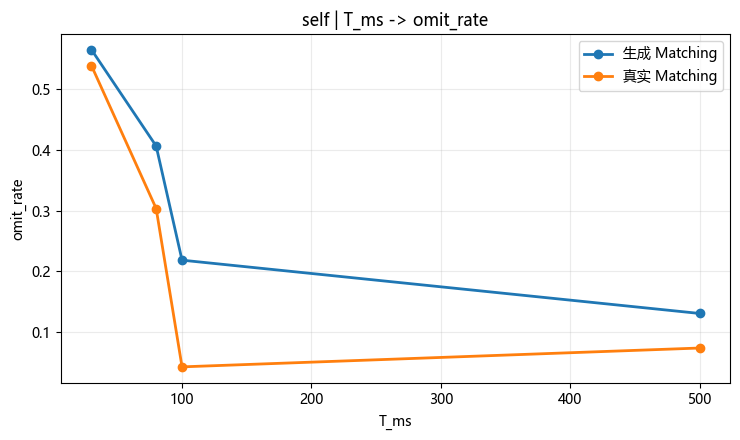

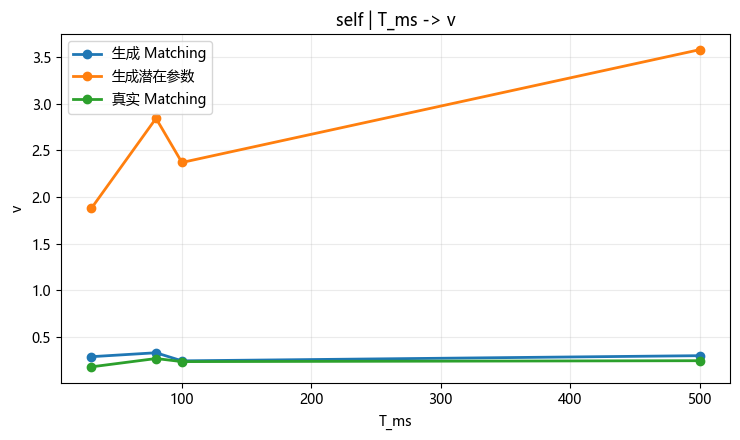

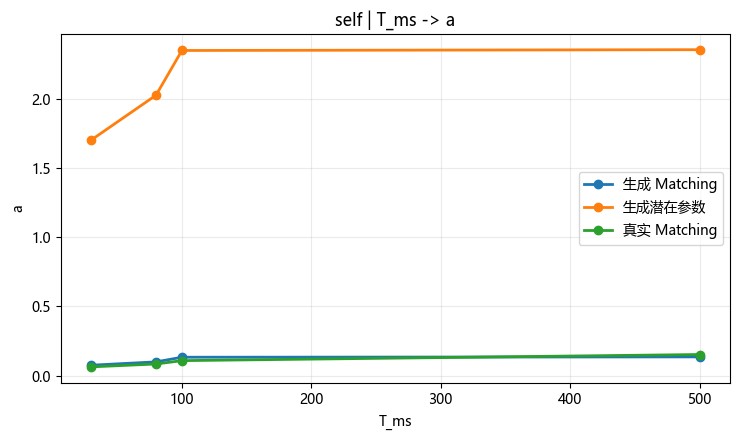

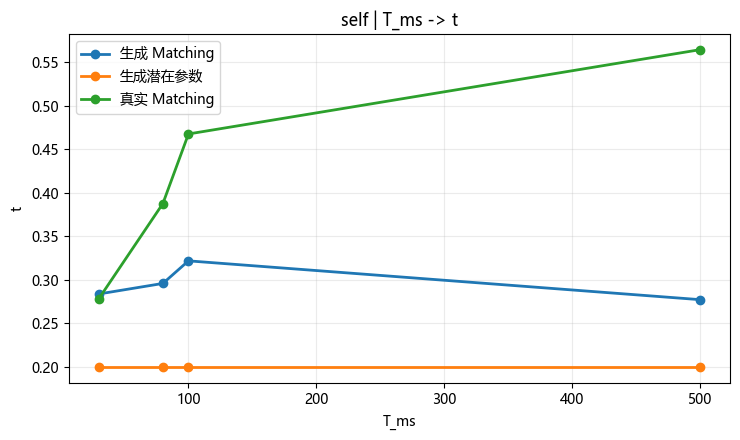

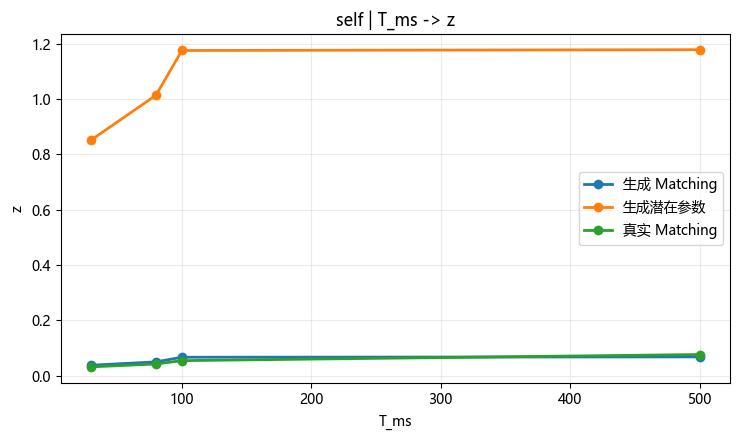

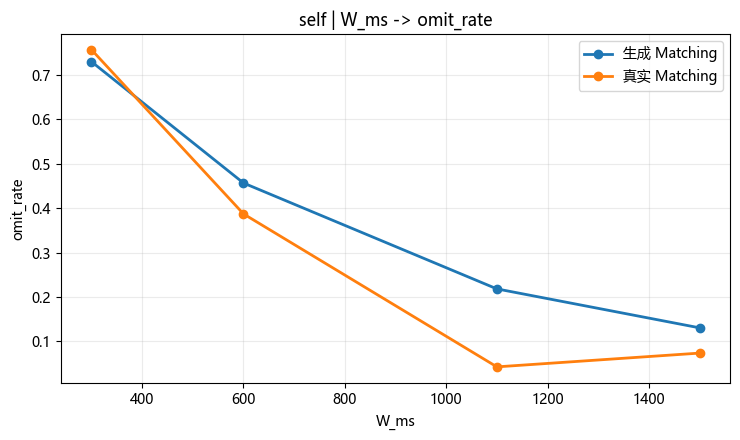

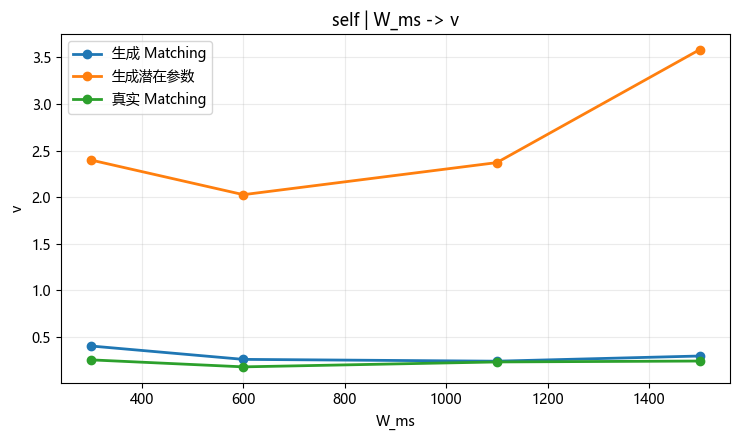

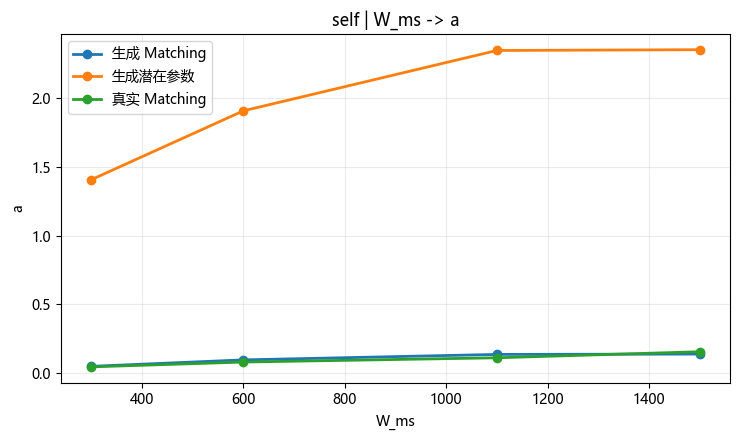

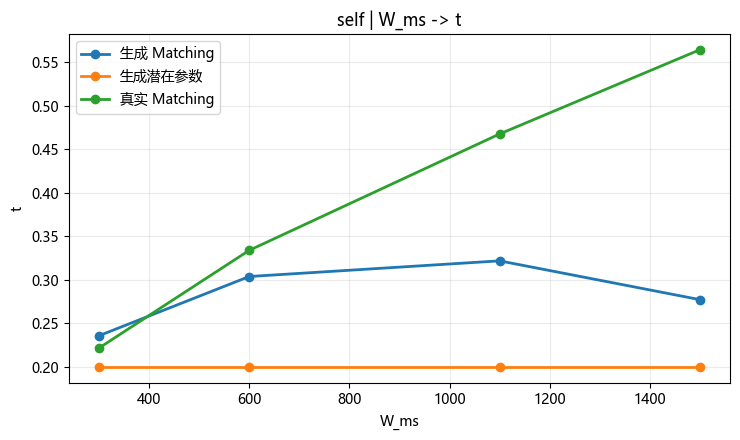

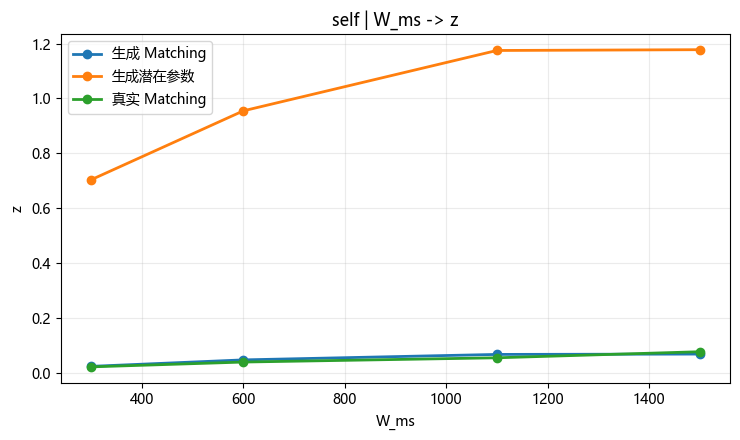

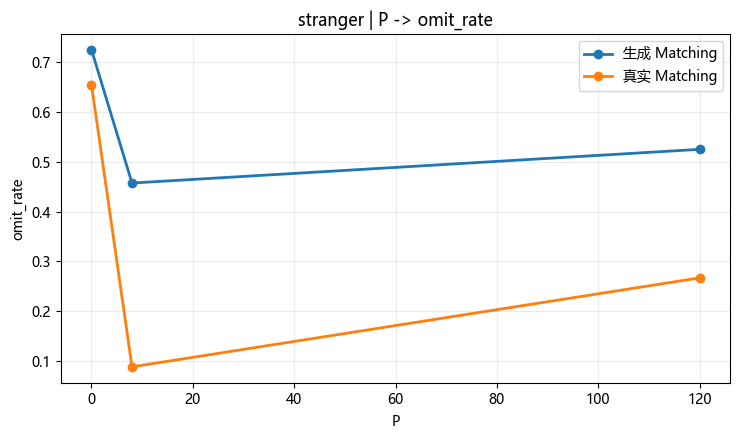

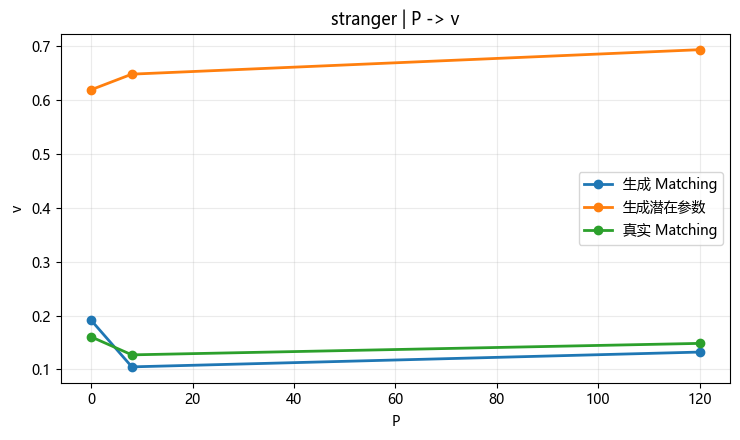

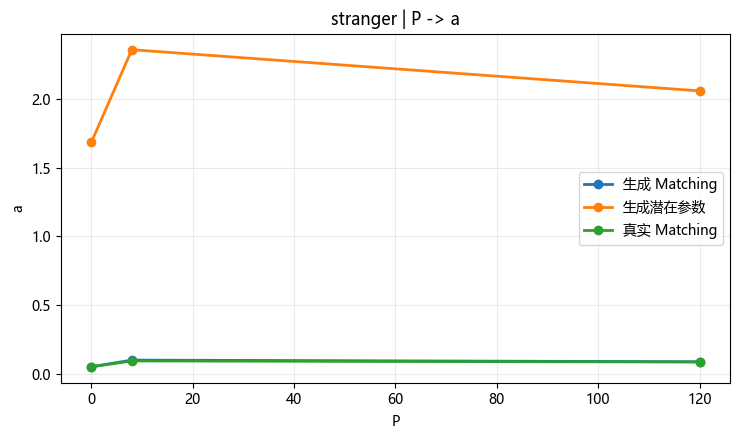

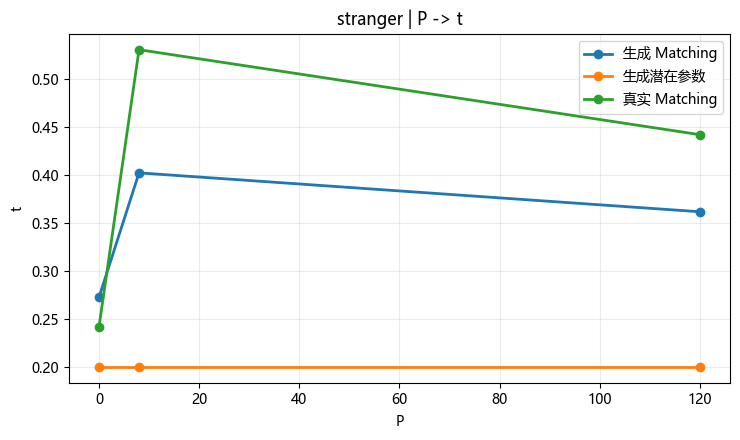

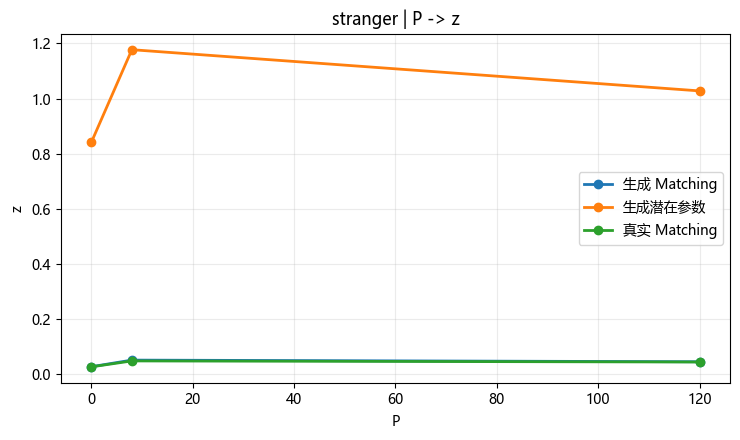

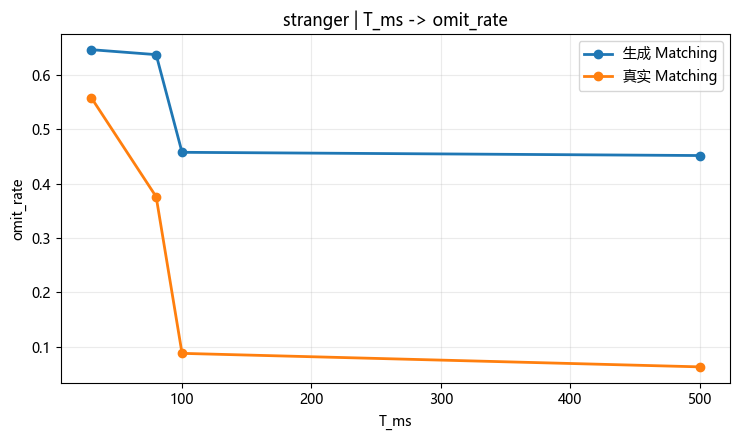

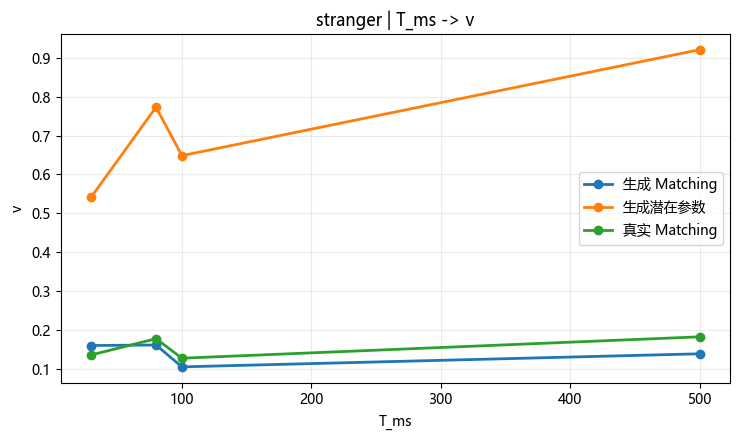

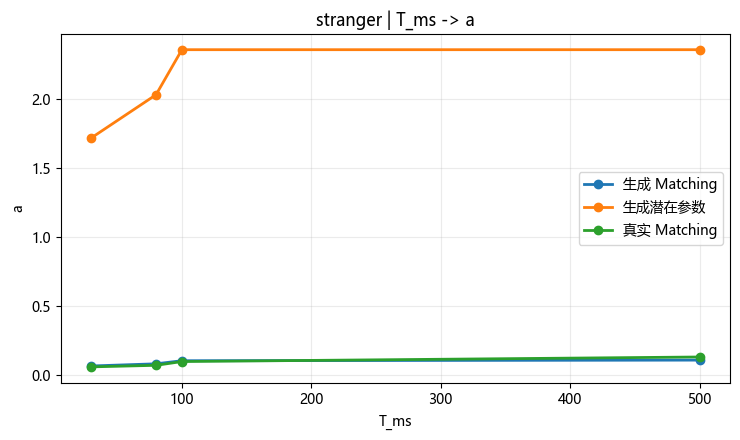

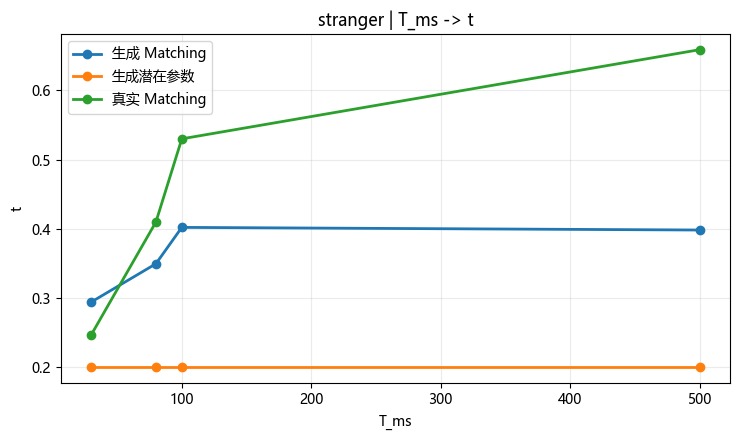

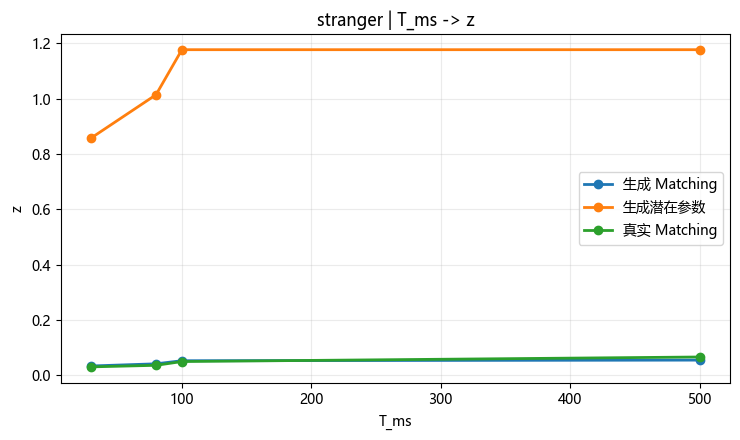

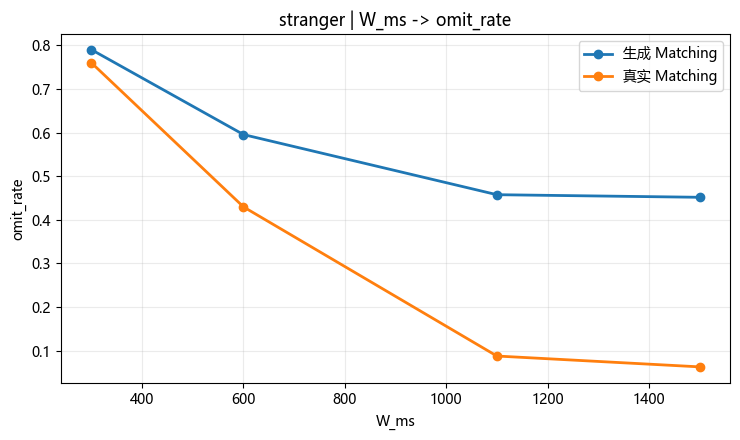

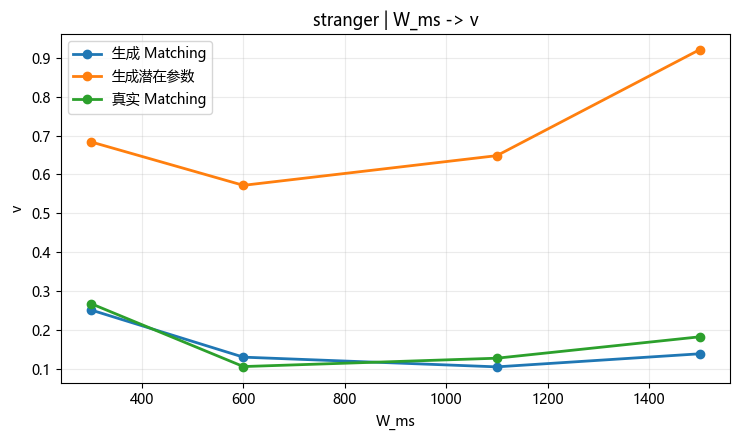

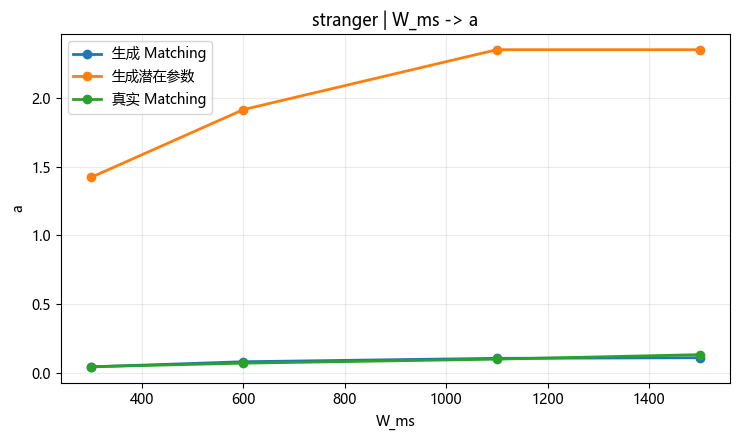

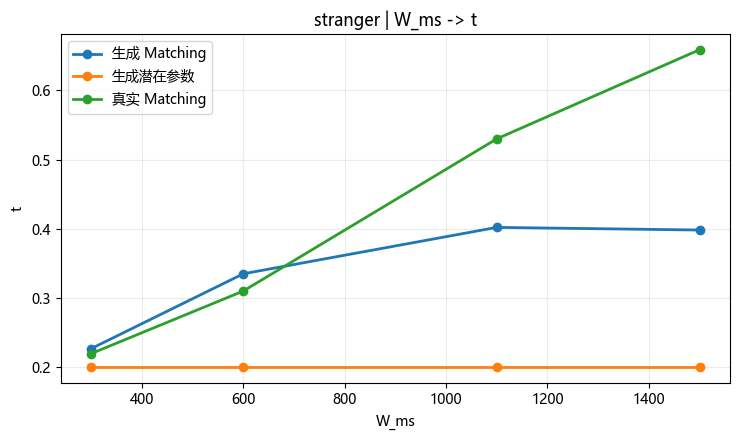

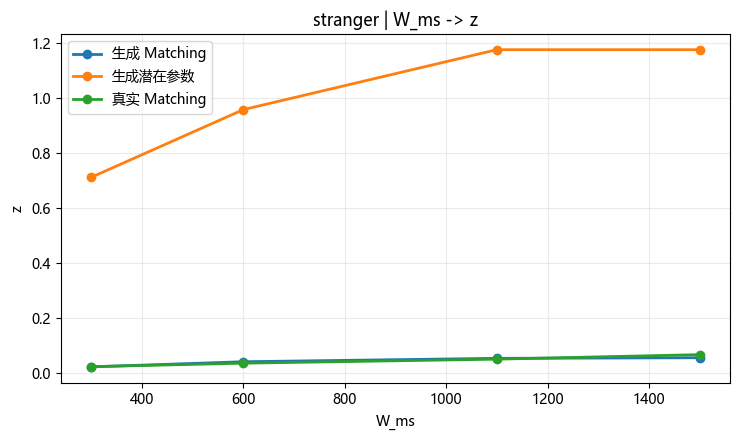

In [12]:
def plot_marginal(df_long, label_value, x_var, metric, save_name=None):
    sub = df_long[df_long['label'] == label_value].copy()
    summary = sub.groupby([x_var, 'source'], as_index=False)[metric].mean().sort_values([x_var, 'source'])
    plt.figure(figsize=(7.5, 4.5))
    for source_name, part in summary.groupby('source'):
        if part[metric].notna().any():
            plt.plot(part[x_var], part[metric], marker='o', linewidth=2, label=source_name)
    plt.xlabel(x_var)
    plt.ylabel(metric)
    plt.title(f'{label_value} | {x_var} -> {metric}')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(compare_long['label'].dropna().unique()):
    for x_var in ['P', 'T_ms', 'W_ms']:
        for metric in ['omit_rate', 'v', 'a', 't', 'z']:
            plot_marginal(compare_long, label, x_var, metric, save_name=f'{label}_{x_var}_{metric}_marginal_v2.4.4.png')

## 六、回答这次比较的合理性

这版比较逻辑比不考虑 `NA` 的版本更合理，原因是：

1. **Matching-only 一致**：真实数据主分析只保留 `Matching`，与生成模型假设一致。
2. **NA 不再被误当成错误**：漏答率 `omit_rate` 被单独比较，而不是混进标准正确率里。
3. **参数估计更干净**：`v / a / t / z` 只由 answered trials 反推，更接近经典 DDM 的二元决策假设。
4. **行为与参数双重检查**：如果模型在 `omit_rate` 上对不上，即使 `RT / ACC` 看起来还可以，也说明模型没有真正抓住 deadline 机制。

因此，当前最推荐的拟合判断顺序是：

1. 先看 `omit_rate` 是否随 `T / W` 呈现和真实数据一致的趋势；
2. 再看 answered trials 上的 `RT / ACC`；
3. 最后看 `v / a / t / z` 的趋势是否对得上。

In [13]:
summary_table = alignment_df.copy()
summary_table.to_csv(FIG_DIR / 'trend_alignment_summary_v2.4.4.csv', index=False)
compare_cond.to_csv(FIG_DIR / 'condition_level_param_compare_v2.4.4.csv', index=False)
compare_long.to_csv(FIG_DIR / 'condition_level_long_compare_v2.4.4.csv', index=False)
real_match.to_csv(FIG_DIR / 'real_matching_trials_with_omit_flag_v2.4.4.csv', index=False)

print('已输出结果到:', FIG_DIR)
display(summary_table)

已输出结果到: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Compare_Real_Generated_DDM_Params_v2.4.4


,label,param,spearman_real_vs_gen_est,spearman_real_vs_gen_latent
0,self,omit_rate,0.942857,NaN
1,self,v,0.771429,0.771429
2,self,a,0.942857,1.000000
3,self,t,0.257143,0.130931
4,self,z,0.942857,1.000000
5,stranger,omit_rate,1.000000,NaN
6,stranger,v,0.771429,0.771429
7,stranger,a,0.942857,0.885714
8,stranger,t,0.885714,0.392792
9,stranger,z,0.942857,0.885714
